# Test modèle — [RUN PATH]
Évaluation d'un modèle entraîné par l'agent sur les données de test.

## 1. Setup & imports

In [1]:
import json
import joblib
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, precision_score,
    confusion_matrix, classification_report
)

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 100

## 2. Configuration

In [2]:
# ── À adapter pour chaque run ────────────────────────────────────────────────
RESULT_PATH = r"../results/agent_runs/creditcard_001_001/20260626_163324"
# ────────────────────────────────────────────────────────────────────────────

## 3. Chargement des informations de la run

In [3]:
result_dir = Path(RESULT_PATH)

with open(result_dir / "summary.json") as f:
    summary = json.load(f)

with open(result_dir / "trial_log.json") as f:
    trial_log = json.load(f)

best = summary["best_trial"]
prepared_run = summary["prepared_run"]

# Retrouver le dossier des données préparées (remonte depuis results/ vers la racine)
root = result_dir.parent.parent.parent.parent  # results/agent_runs/<ds>/<ts> → root
prepared_dir = root / "data" / "02_prepared" / prepared_run

with open(prepared_dir / "metadata.json") as f:
    prep_meta = json.load(f)

TARGET_COL = prep_meta["target_column"]
FEATURE_COLS = prep_meta["feature_columns"]
print(f"Run      : {result_dir.name}")
print(f"Dataset  : {prepared_run}")
print(f"Target   : {TARGET_COL}")
print(f"Features : {len(FEATURE_COLS)}")

Run      : 20260626_163324
Dataset  : creditcard_001_001
Target   : Class
Features : 30


## 4. Informations sur la run

In [4]:
print("=" * 55)
print(f"  Modèle        : {best['model_type']}")
print(f"  Objectif      : {summary['objective']}")
print(f"  Runs agent    : {summary['runs_used']} / {summary['max_runs']}")
print(f"  Arrêt         : {summary['stop_reason']}")
print(f"  Best run_id   : {best['run_id']}")
print("-" * 55)
print("  Hyperparamètres :")
for k, v in best["hyperparameters"].items():
    print(f"    {k:<25} {v}")
print("-" * 55)
print(f"  train_f1      : {best['train_f1']:.4f}")
print(f"  eval_f1       : {best['eval_f1']:.4f}")
print(f"  Écart (overfit): {best['train_f1'] - best['eval_f1']:.4f}")
print("=" * 55)

  Modèle        : hist_gradient_boosting
  Objectif      : maximize eval_f1
  Runs agent    : 6 / 10
  Arrêt         : convergence (gain < 0.001 sur 3 essais)
  Best run_id   : 4
-------------------------------------------------------
  Hyperparamètres :
    max_iter                  260
    max_depth                 6
    learning_rate             0.047309442068985116
    l2_regularization         0.9041986740582306
-------------------------------------------------------
  train_f1      : 0.9800
  eval_f1       : 0.9285
  Écart (overfit): 0.0515


## 5. Historique des essais

In [5]:
trials_df = pd.DataFrame([
    {
        "run_id": t["run_id"],
        "model_type": t["model_type"],
        **t["hyperparameters"],
        "train_f1": round(t["train_f1"], 4),
        "eval_f1": round(t["eval_f1"], 4),
        "gap": round(t["train_f1"] - t["eval_f1"], 4),
        "best": t["run_id"] == best["run_id"],
    }
    for t in trial_log
])

display(trials_df)

,run_id,model_type,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,train_f1,eval_f1,gap,best,max_iter,l2_regularization
0,1,xgboost,100.0,4,0.100000,0.8,0.8,0.9685,0.9189,0.0496,False,NaN,NaN
1,2,xgboost,80.0,3,0.150000,0.9,0.9,0.9494,0.8998,0.0496,False,NaN,NaN
2,3,hist_gradient_boosting,NaN,8,0.087739,NaN,NaN,0.9893,0.9276,0.0616,False,230.0,0.440527
3,4,hist_gradient_boosting,NaN,6,0.047309,NaN,NaN,0.9800,0.9285,0.0515,True,260.0,0.904199
4,5,hist_gradient_boosting,NaN,6,0.047309,NaN,NaN,0.9800,0.9285,0.0515,False,310.0,0.904199
5,6,hist_gradient_boosting,NaN,4,0.025898,NaN,NaN,0.9553,0.9161,0.0393,False,400.0,0.920223


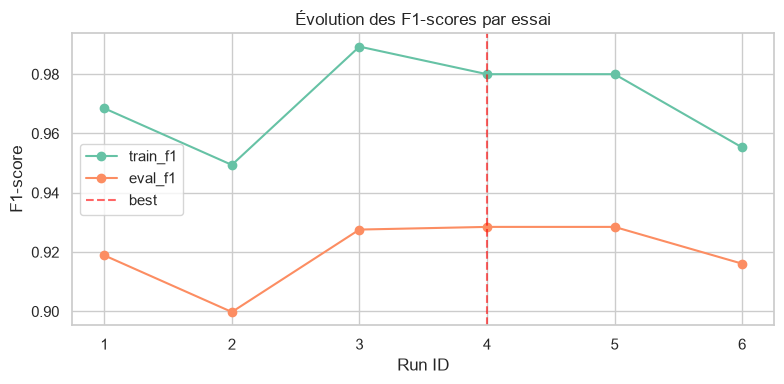

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(trials_df["run_id"], trials_df["train_f1"], marker="o", label="train_f1")
ax.plot(trials_df["run_id"], trials_df["eval_f1"],  marker="o", label="eval_f1")
best_row = trials_df[trials_df["run_id"] == best["run_id"]].iloc[0]
ax.axvline(best_row["run_id"], color="red", linestyle="--", alpha=0.6, label="best")
ax.set_xlabel("Run ID")
ax.set_ylabel("F1-score")
ax.set_title("Évolution des F1-scores par essai")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Chargement du modèle et des données de test

In [7]:
model_bundle = joblib.load(result_dir / "best_model.joblib")
model         = model_bundle["model"]
label_encoder = model_bundle.get("label_encoder")   # None si absent
FEATURE_COLS  = model_bundle.get("feature_columns", FEATURE_COLS)

test_df = pd.read_csv(prepared_dir / "test.csv")
X_test = test_df[FEATURE_COLS]
y_test = test_df[TARGET_COL]

print(f"Test set : {X_test.shape[0]} lignes, {X_test.shape[1]} features")
print(f"Distribution des classes :")
vc = y_test.value_counts().sort_index()
display(pd.DataFrame({"count": vc, "%": (vc / len(y_test) * 100).round(2)}))

Test set : 55810 lignes, 30 features
Distribution des classes :


,count,%
Class,,
0,55715,99.83
1,95,0.17


## 7. Évaluation sur le test set

In [8]:
y_pred = model.predict(X_test)
classes = sorted(y_test.unique())
average = "binary" if len(classes) == 2 else "macro"

### 7.1 Tableau des métriques

In [9]:
metrics = {
    "Accuracy":  accuracy_score(y_test, y_pred),
    "F1-score":  f1_score(y_test, y_pred, average=average, zero_division=0),
    "Recall":    recall_score(y_test, y_pred, average=average, zero_division=0),
    "Precision": precision_score(y_test, y_pred, average=average, zero_division=0),
}

metrics_df = pd.DataFrame(
    {"Métrique": list(metrics.keys()), "Score (test)": [f"{v:.4f}" for v in metrics.values()]}
).set_index("Métrique")

print(f"Average : {average}")
display(metrics_df)

Average : binary


,Score (test)
Métrique,
Accuracy,0.9995
F1-score,0.8352
Recall,0.8000
Precision,0.8736


In [10]:
# Comparaison test vs eval (agent)
compare_df = pd.DataFrame({
    "Phase":  ["eval (agent)", "test"],
    "F1-score": [best["eval_f1"], metrics["F1-score"]],
    "train_f1": [best["train_f1"], None],
})
display(compare_df)

,Phase,F1-score,train_f1
0,eval (agent),0.928459,0.979967
1,test,0.835165,NaN


### 7.2 Rapport par classe

In [11]:
report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).T.round(4)
display(report_df)

,precision,recall,f1-score,support
0,0.9997,0.9998,0.9997,55715.0000
1,0.8736,0.8000,0.8352,95.0000
accuracy,0.9995,0.9995,0.9995,0.9995
macro avg,0.9366,0.8999,0.9174,55810.0000
weighted avg,0.9994,0.9995,0.9995,55810.0000


### 7.3 Matrice de confusion

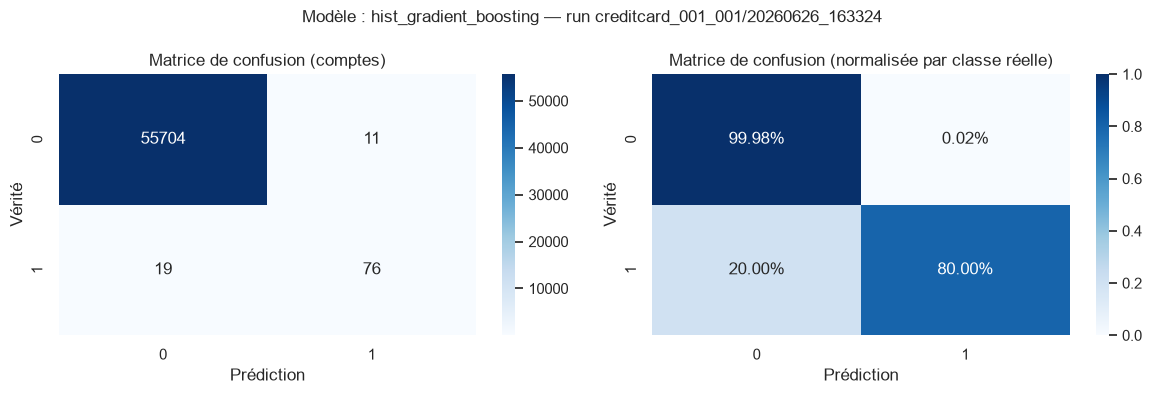

In [12]:
cm = confusion_matrix(y_test, y_pred, labels=classes)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Counts
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes, ax=axes[0])
axes[0].set_title("Matrice de confusion (comptes)")
axes[0].set_xlabel("Prédiction")
axes[0].set_ylabel("Vérité")

# Normalized by true class
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap="Blues",
            xticklabels=classes, yticklabels=classes, ax=axes[1],
            vmin=0, vmax=1)
axes[1].set_title("Matrice de confusion (normalisée par classe réelle)")
axes[1].set_xlabel("Prédiction")
axes[1].set_ylabel("Vérité")

plt.suptitle(f"Modèle : {best['model_type']} — run {result_dir.parent.name}/{result_dir.name}",
             fontsize=12)
plt.tight_layout()
plt.show()

## 8. Conclusion

**Modèle :** …

**Métriques test :**
- Accuracy : …
- F1-score : …
- Recall : …
- Precision : …

**Généralisation :**
- Écart eval → test : …
- Overfitting observé : …

**Points d'attention :**
- …